In [ ]:
import warnings
# Esto silencia todas las advertencias
warnings.filterwarnings('ignore')

Explorando el conjunto de Datos


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('heart_disease.csv')

print("--- INFO GENERAL ---")
df.info()

print("\n--- RECUENTO DE NULOS ---")
print(df.isnull().sum())

print("\n--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TenYearCHD) ---")
print(df['TenYearCHD'].value_counts(normalize=True))

--- INFO GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 5

Generación de graficos

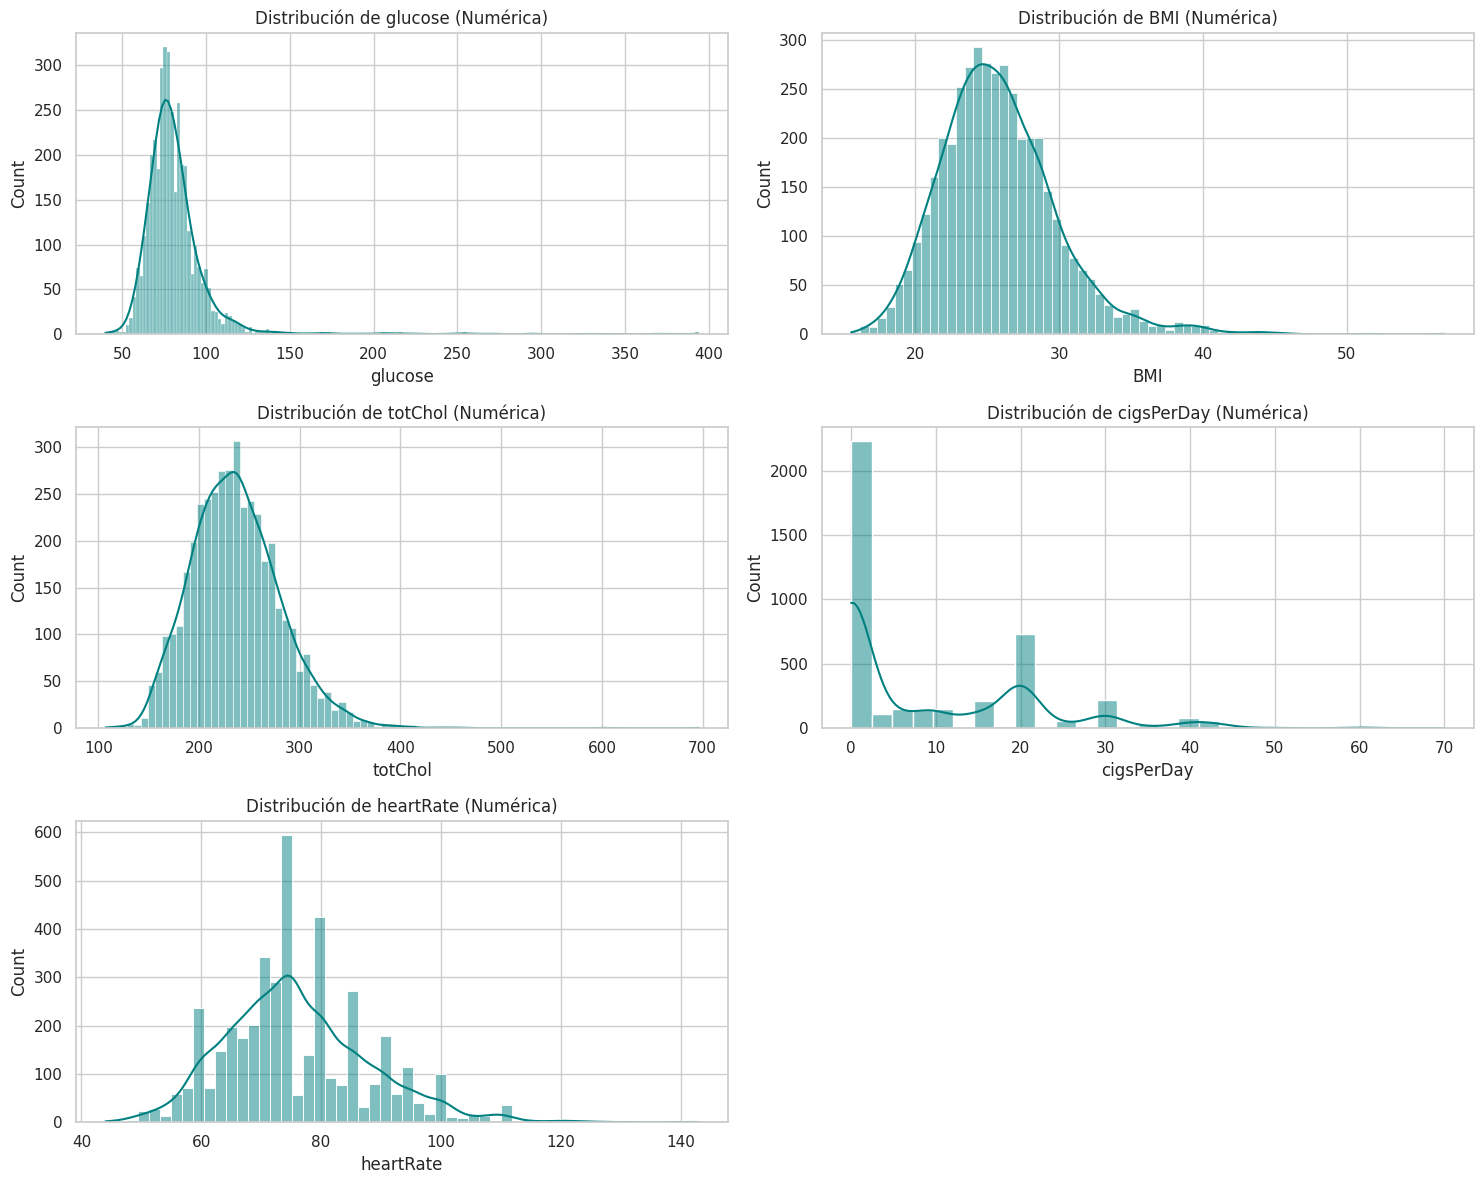

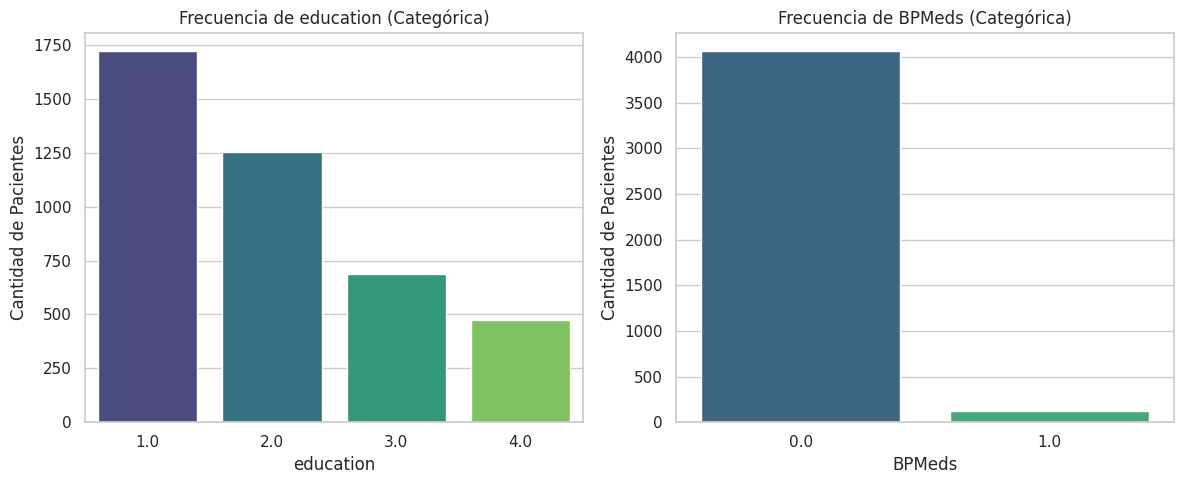

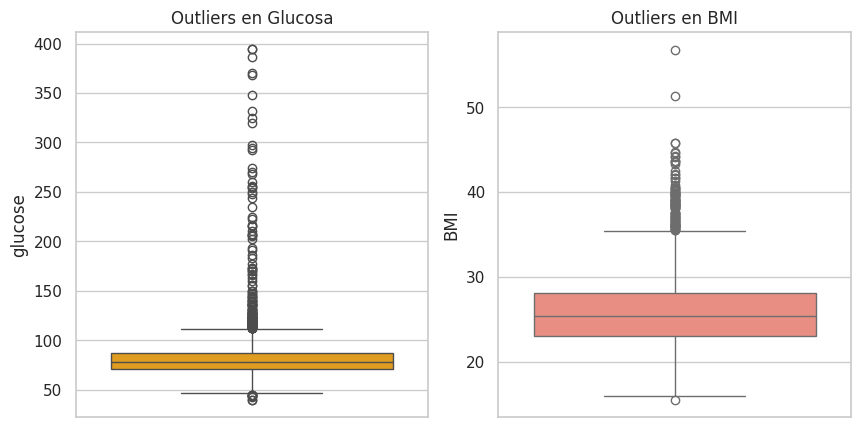

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --- GRUPO 1: VARIABLES NUMÉRICAS CONTINUAS ---
# Aquí buscamos outliers
continuous_cols = ['glucose', 'BMI', 'totChol', 'cigsPerDay', 'heartRate']

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col].dropna(), kde=True, color='teal')
    plt.title(f'Distribución de {col} (Numérica)')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# --- GRUPO 2: VARIABLES CATEGÓRICAS ---
# Aquí buscamos cuál es la categoría más común
categorical_cols = ['education', 'BPMeds']

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=df[col].dropna(), palette='viridis')
    plt.title(f'Frecuencia de {col} (Categórica)')
    plt.xlabel(col)
    plt.ylabel('Cantidad de Pacientes')

plt.tight_layout()
plt.show()

# --- GRUPO 3: DETECCIÓN DE OUTLIERS ESPECÍFICOS ---
# Boxplots para las variables más sensibles a valores extremos
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['glucose'], color='orange')
plt.title('Outliers en Glucosa')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['BMI'], color='salmon')
plt.title('Outliers en BMI')
plt.show()

Imputación de datos

In [ ]:
# 1. Definimos las estrategias basadas en nuestro análisis visual
# Numéricas -> Mediana
cols_mediana = ['glucose', 'BMI', 'totChol', 'cigsPerDay', 'heartRate']

# Categóricas -> Moda
cols_moda = ['education', 'BPMeds']

# 2. Aplicamos la imputación
# Para las numéricas
for col in cols_mediana:
    valor_mediana = df[col].median()
    df[col].fillna(valor_mediana, inplace=True)
    print(f"Variable '{col}': Imputados {df[col].isnull().sum()} nulos con la Mediana ({valor_mediana})")

# Para las categóricas
for col in cols_moda:
    valor_moda = df[col].mode()[0]
    df[col].fillna(valor_moda, inplace=True)
    print(f"Variable '{col}': Imputados nulos con la Moda ({valor_moda})")

# 3. Verificación final
print("\n--- RECUENTO FINAL DE NULOS ---")
print(df.isnull().sum())

Variable 'glucose': Imputados 0 nulos con la Mediana (78.0)
Variable 'BMI': Imputados 0 nulos con la Mediana (25.4)
Variable 'totChol': Imputados 0 nulos con la Mediana (234.0)
Variable 'cigsPerDay': Imputados 0 nulos con la Mediana (0.0)
Variable 'heartRate': Imputados 0 nulos con la Mediana (75.0)
Variable 'education': Imputados nulos con la Moda (1.0)
Variable 'BPMeds': Imputados nulos con la Moda (0.0)

--- RECUENTO FINAL DE NULOS ---
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


Análisis de Selección de Características

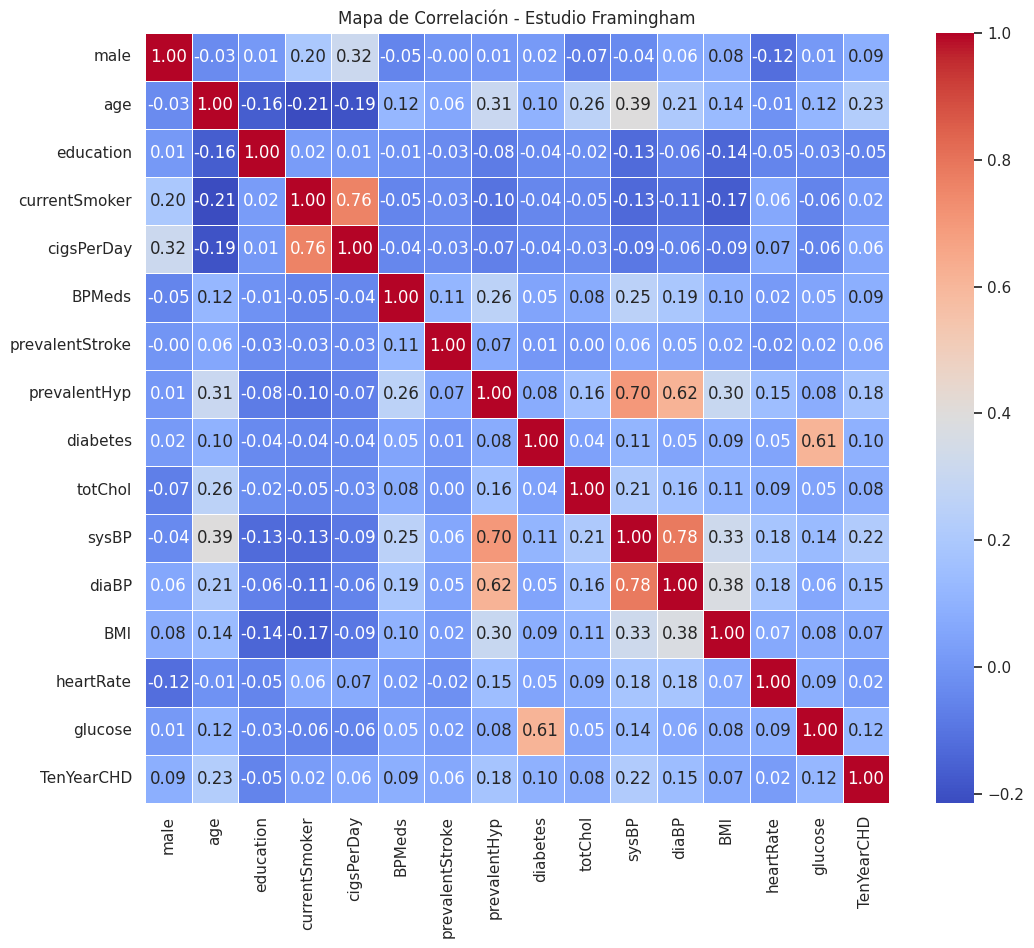

Ranking de variables que más influyen en el Riesgo Cardiaco (TenYearCHD):
TenYearCHD         1.000000
age                0.225256
sysBP              0.216429
prevalentHyp       0.177603
diaBP              0.145299
glucose            0.121277
diabetes           0.097317
male               0.088428
BPMeds             0.086417
totChol            0.081566
BMI                0.074217
prevalentStroke    0.061810
cigsPerDay         0.058859
heartRate          0.022857
currentSmoker      0.019456
education         -0.052812
Name: TenYearCHD, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la correlación matemática entre todas las columnas
matriz_correlacion = df.corr()

# 2. Visualización: El Mapa de Calor
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title("Mapa de Correlación - Estudio Framingham")
plt.show()

print("Ranking de variables que más influyen en el Riesgo Cardiaco (TenYearCHD):")
print(matriz_correlacion['TenYearCHD'].sort_values(ascending=False))

Generación de Grupos de Entrenamiento y Validación

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Selección de Características
# Eliminamos 'currentSmoker' por ser redundante
# Eliminamos 'TenYearCHD' porque es la respuesta que queremos predecir
X = df.drop(['TenYearCHD', 'currentSmoker'], axis=1)
y = df['TenYearCHD']

# 2. División de Datos (Train/Test Split)
# test_size=0.2  -> Guardamos el 20% para validar
# random_state=42 -> Para que siempre nos salga la misma división
# stratify=y -> Para mentener la proporción de enfermos igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1994, stratify=y)

# 3. Normalización (Escalado)
scaler = StandardScaler()

# Aprendemos la escala del grupo de estudio y los transformamos
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos esa misma escala al grupo de validación (sin aprender de ellos)
X_test_scaled = scaler.transform(X_test)

# 4. Verificación de datos
print(f"Total de pacientes originales: {df.shape[0]}")
print(f"Pacientes para Entrenar (80%): {X_train.shape[0]}")
print(f"Pacientes para Validar (20%):  {X_test.shape[0]}")

print("\n--- Verificación de Balance (Estratificación) ---")
print(f"Porcentaje de enfermos en Entrenamiento: {y_train.mean():.2%}")
print(f"Porcentaje de enfermos en Validación:    {y_test.mean():.2%}")

Total de pacientes originales: 4238
Pacientes para Entrenar (80%): 3390
Pacientes para Validar (20%):  848

--- Verificación de Balance (Estratificación) ---
Porcentaje de enfermos en Entrenamiento: 15.19%
Porcentaje de enfermos en Validación:    15.21%


Instancia y Entrenamiento del Modelo

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instanciar el modelo
# Cambiamos random_state a 1994 para originalidad.
# class_weight='balanced' lo usamos para balancear los resultados
modelo = LogisticRegression(random_state=1994, max_iter=1000, class_weight='balanced')

# 2. Entrenar el modelo
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo de Regresión Logística entrenado exitosamente.")
print(f"Parámetros usados: {modelo.get_params()}")

✅ Modelo de Regresión Logística entrenado exitosamente.
Parámetros usados: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 1994, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


Cálculo de Métricas y Evaluación

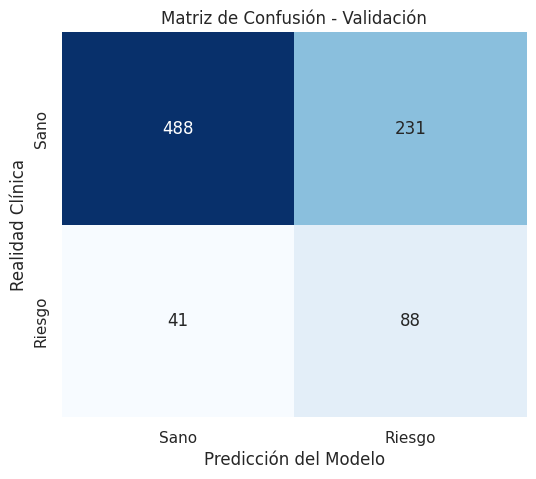


--- REPORTE DE CLASIFICACIÓN) ---
              precision    recall  f1-score   support

           0       0.92      0.68      0.78       719
           1       0.28      0.68      0.39       129

    accuracy                           0.68       848
   macro avg       0.60      0.68      0.59       848
weighted avg       0.82      0.68      0.72       848

Exactitud Global (Accuracy): 67.92%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Realizar predicciones sobre el conjunto de validación (Test)
# Usamos X_test_scaled porque el modelo se entreno con data escalada
y_pred = modelo.predict(X_test_scaled)

# 2. Matriz de Confusión Gráfica
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Sano', 'Riesgo'], yticklabels=['Sano', 'Riesgo'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad Clínica')
plt.title('Matriz de Confusión - Validación')
plt.show()

# 3. Métricas Numéricas
print("\n--- REPORTE DE CLASIFICACIÓN) ---")
print(classification_report(y_test, y_pred))

print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.2%}")

En este proyecto he desarrollado un modelo predictivo para el riesgo cardiovascular a 10 años (Framingham). Dado el severo desbalance de las clases (solo 15% de casos positivos), hemos priorizado la métrica de Recall (Sensibilidad) sobre la Exactitud global.

Al utilizar una regresión logística con pesos balanceados (class_weight='balanced'), obtuvimos una Exactitud y un Recall cercanos al 68%. Aunque a primera vista parece una métrica moderada, este resultado refleja una estrategia clínica intencional:

Detección Prioritaria: El algoritmo es capaz de detectar a casi 7 de cada 10 pacientes con riesgo real (88 vidas potencialmente salvadas). Sin este ajuste, el modelo habría maximizado su exactitud matemática ignorando a casi la totalidad de los 129 pacientes de riesgo.

Costo de Oportunidad: Hemos aceptado una tasa mayor de Falsos Positivos (231 pacientes sanos alertados preventivamente) y una Precisión baja (0.28) como un costo necesario para cumplir con el principio médico de precaución.

Respecto a los 41 casos no detectados (Falsos Negativos), aunque técnicamente sería posible ajustar el umbral de decisión (por debajo del 50%) para capturarlos, hemos decidido mantener el umbral estándar. Esta decisión se fundamenta en un criterio de sostenibilidad sanitaria y protección económica del paciente: reducir más el umbral aumentaría drásticamente las falsas alarmas, obligando a pacientes humildes a costear pruebas innecesarias y saturando los servicios de salud.

En conclusión, el modelo actual ofrece el mejor balance ético posible: actúa como una herramienta de apoyo al diagnóstico responsable, que maximiza la detección de patologías sin comprometer la viabilidad económica para el paciente ni la eficiencia del sistema sanitario.

In [ ]:
# Exportar a PDF
import json, re
from google.colab import files, _message

nombre = input("Nombre del cuaderno (con o sin .ipynb): ").strip() or "Cuaderno"
nombre = re.sub(r"\.ipynb$", "", nombre, flags=re.IGNORECASE).strip()
base   = re.sub(r"[^\w.-]+", "_", nombre) or "Cuaderno"
ipynb  = f"{base}.ipynb"

nb = _message.blocking_request('get_ipynb')['ipynb']
style = """

"""
nb['cells'].insert(0, {"cell_type": "markdown", "metadata": {"hide_input": True}, "source": [style]})

with open(ipynb, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False)

!pip -q install nbconvert[webpdf]
!jupyter nbconvert --to webpdf --allow-chromium-download "{ipynb}" --output "{base}"

files.download(f"{base}.pdf")

Nombre del cuaderno (con o sin .ipynb): Practica2_Josue_Diaz_Contreras
[NbConvertApp] Converting notebook Practica2_Josue_Diaz_Contreras.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 539643 bytes to Practica2_Josue_Diaz_Contreras.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>